# Setup


In [1]:
# Load packages.
import os
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from torch.utils.data import DataLoader, TensorDataset

import utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
importlib.reload(utils)

Using device: cuda


<module 'utils' from '/tscc/projects/ps-yeolab3/kflanagan/plip_plop/machine_learning_prototype/utils.py'>

## Rebuild the validation data

This reproduces the preprocessing and region-level split used by `many_RBP_prototype.ipynb`, so the notebook works from a fresh kernel.


In [2]:
INPUT_DIR = "/tscc/lustre/ddn/scratch/kflanagan/plip_plop_results/processed_inputs"
COMPARISON_TABLE = (
    "/tscc/nfs/home/kflanagan/projects/plip_plop/"
    "machine_learning_prototype/encode_initial_30_comparisons.tsv"
)
MODEL_PATH = (
    "/tscc/nfs/home/kflanagan/scratch/plip_plop_results/"
    "many_IN_RBP_baseline.pt"
)

comparison_table = pd.read_csv(COMPARISON_TABLE, sep="\t")

expected_files = [
    os.path.join(INPUT_DIR, f"{row.experiment_A}_{row.experiment_B}.npz")
    for row in comparison_table.itertuples(index=False)
]
missing_files = [path for path in expected_files if not os.path.exists(path)]

if missing_files:
    preview = "\n".join(missing_files[:5])
    raise FileNotFoundError(
        f"Missing {len(missing_files)} expected input file(s). First missing file(s):\n{preview}"
    )

print(f"Found all {len(expected_files)} comparison files.")


Found all 30 comparison files.


In [3]:
all_signals = []
all_metadata = []

for comparison_id, row in comparison_table.iterrows():
    experiment_A = row["experiment_A"]
    experiment_B = row["experiment_B"]

    npz_file = os.path.join(INPUT_DIR, f"{experiment_A}_{experiment_B}.npz")

    if not os.path.exists(npz_file):
        print(f"Missing: {npz_file}")
        continue

    data = np.load(npz_file)

    # Load the final abundance-corrected, smoothed signal.
    signals = data["signals"].astype(np.float32)
    n_windows = len(signals)

    all_signals.append(signals)

    metadata = pd.DataFrame({
        "comparison_id": comparison_id,
        "category": row["category"],
        "experiment_A": experiment_A,
        "experiment_B": experiment_B,
        "chrom": data["chrom"],
        "start": data["start"],
        "end": data["end"],
        "strand": data["strand"],
        "region_id": data["region_id"],
        "block_number": data["block_number"],
        "signal_A": data["total_signal_A"],
        "signal_B": data["total_signal_B"],
        "total_signal": data["total_signal"]
    })

    all_metadata.append(metadata)

signals = np.concatenate(all_signals, axis=0)
metadata = pd.concat(all_metadata, ignore_index=True)

In [4]:
comparison_counts = (
    metadata
    .groupby(["comparison_id", "category", "experiment_A", "experiment_B"])
    .size()
    .reset_index(name="n_windows")
    .sort_values("n_windows", ascending=False)
)

In [5]:
# Set weighting alpha to 0.5 (square root).
alpha = 0.5

# Create the comparison weights.
comparison_counts["comparison_weight"] = comparison_counts["n_windows"] ** (alpha - 1)

# Create a dictionary for quickly grabbing each weight for each comparison.
weight_map = dict(zip(comparison_counts["comparison_id"], comparison_counts["comparison_weight"]))

# Add comparison weights to metadata.
metadata["comparison_weight"] = metadata["comparison_id"].map(weight_map)

# Use log-transformed total IP signal for window weighting.
metadata["signal_weight"] = np.log1p(metadata["total_signal"])

# Normalize signal weights within each comparison.
metadata["signal_weight"] = (
    metadata["signal_weight"] /
    metadata.groupby("comparison_id")["signal_weight"].transform("mean")
)

# Create the final weight.
metadata["weight"] = metadata["comparison_weight"] * metadata["signal_weight"]

# Split whole merged regions, never individual neighboring blocks.
metadata["region_key"] = (
    metadata["comparison_id"].astype(str)
    + "_"
    + metadata["region_id"].astype(str)
)

rng = np.random.default_rng(42)
val_mask = np.zeros(len(metadata), dtype=bool)

for comparison_id in metadata["comparison_id"].unique():
    comparison_rows = metadata["comparison_id"] == comparison_id
    comparison_regions = metadata.loc[
        comparison_rows, "region_key"
    ].drop_duplicates().to_numpy(dtype=object, copy=True)
    rng.shuffle(comparison_regions)

    split = int(len(comparison_regions) * 0.8)
    val_regions = comparison_regions[split:]
    val_mask |= metadata["region_key"].isin(val_regions).to_numpy()

val_signals = signals[val_mask]
val_metadata = metadata.loc[val_mask].reset_index(drop=True)
val_weights = val_metadata["weight"].to_numpy(dtype=np.float32)

val_dataset = TensorDataset(
    torch.from_numpy(val_signals),
    torch.from_numpy(val_weights),
)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

print("Validation windows:", len(val_dataset))
print("Validation comparisons:", val_metadata["comparison_id"].nunique())


Validation windows: 143119
Validation comparisons: 30


## Load the trained model


In [6]:
model = utils.SimpleAutoencoder(latent_dim=64).to(device)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()
print("Loaded model:", MODEL_PATH)


Loaded model: /tscc/nfs/home/kflanagan/scratch/plip_plop_results/many_IN_RBP_baseline.pt


# Clustering/PCA

## Window-level PCA

In [7]:
pca, pca_df, latent_vectors, validation_signals = utils.build_validation_pca(
    model, val_loader, val_metadata, device
)

print("Window latent vectors:", latent_vectors.shape)
print("PC1 + PC2 explained variance:", pca.explained_variance_ratio_.sum())


Window latent vectors: (143119, 64)
PC1 + PC2 explained variance: 0.85647756


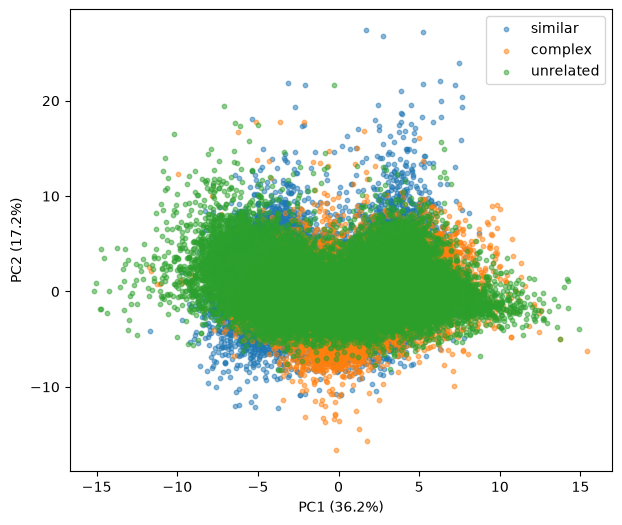

In [8]:
utils.plot_validation_pca(pca_df, pca)


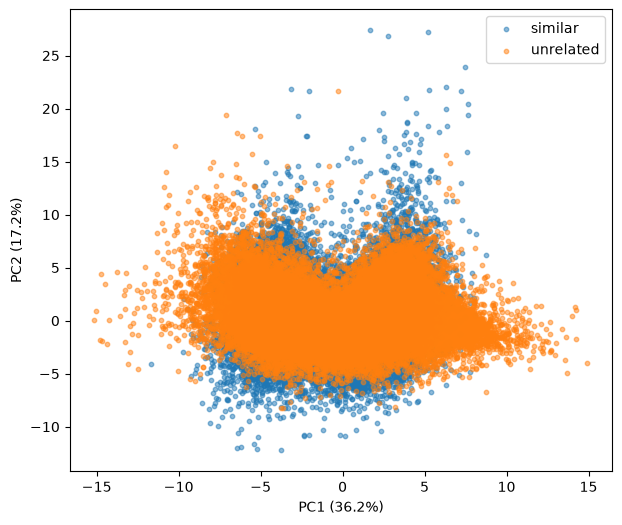

In [9]:
utils.plot_validation_pca(
    pca_df,
    pca,
    categories=["similar", "unrelated"],
)


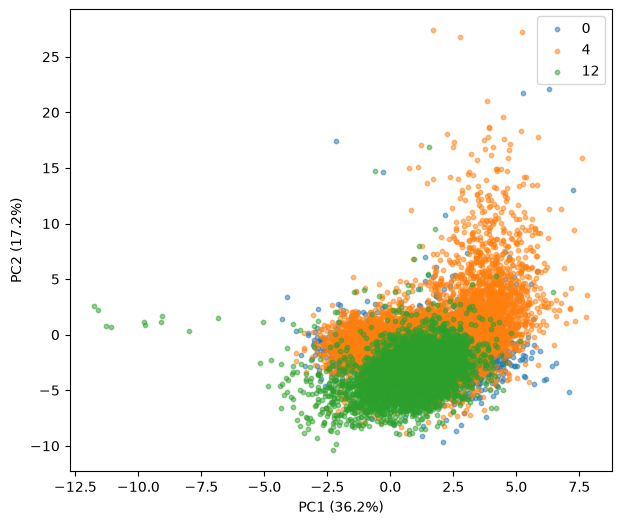

In [10]:
utils.plot_validation_pca(
    pca_df,
    pca,
    comparison_ids=[0, 4, 12],
    color_by="comparison_id",
)


## Mean latent vectors by comparison


In [11]:
comparison_latents, comparison_metadata = utils.build_comparison_latents(
    latent_vectors, val_metadata
)

print("Window latent vectors:", latent_vectors.shape)
print("Comparison latent vectors:", comparison_latents.shape)


Window latent vectors: (143119, 64)
Comparison latent vectors: (30, 64)


In [12]:
comparison_pca = PCA(n_components=2)
comparison_coords = comparison_pca.fit_transform(comparison_latents)

comparison_pca_df = comparison_metadata.copy()
comparison_pca_df["PC1"] = comparison_coords[:, 0]
comparison_pca_df["PC2"] = comparison_coords[:, 1]


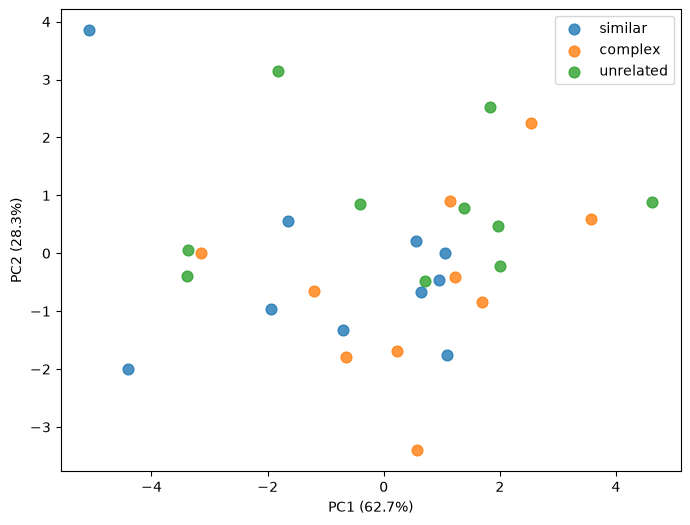

In [13]:
plt.figure(figsize=(8, 6))

for category, group in comparison_pca_df.groupby("category", sort=False):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=60,
        alpha=0.8,
        label=category,
    )

# Uncomment to label every comparison. It is informative but visually crowded.
# for _, row in comparison_pca_df.iterrows():
#     plt.annotate(row["pair_label"], (row["PC1"], row["PC2"]), fontsize=8)

plt.xlabel(f"PC1 ({comparison_pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({comparison_pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend()
plt.show()


## Inspect individual windows at PCA extremes

### PC1


In [14]:
pc1_order = pca_df["PC1"].sort_values().index
pc1_left = pc1_order[:100]
pc1_right = pc1_order[-100:]


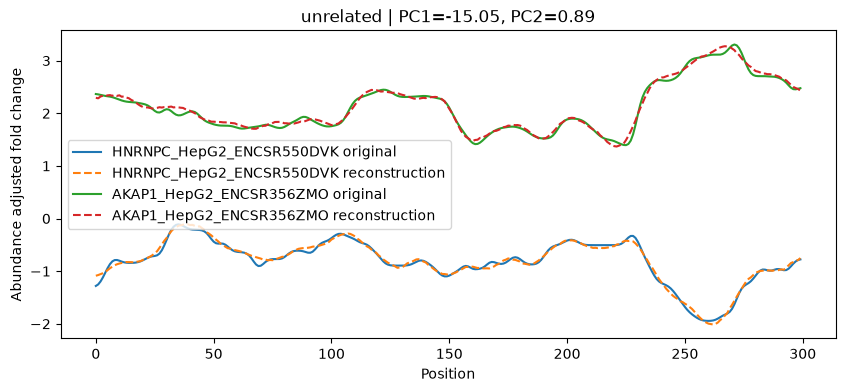

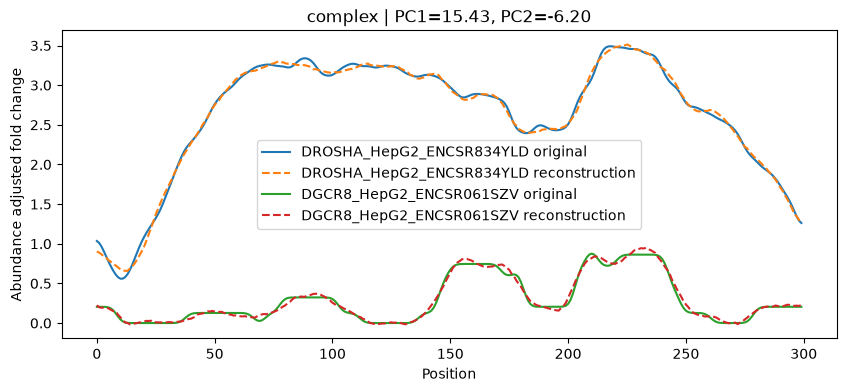

In [15]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc1_left[1]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc1_right[-1]
)


### PC2


In [16]:
pc2_order = pca_df["PC2"].sort_values().index
pc2_bottom = pc2_order[:100]
pc2_top = pc2_order[-100:]

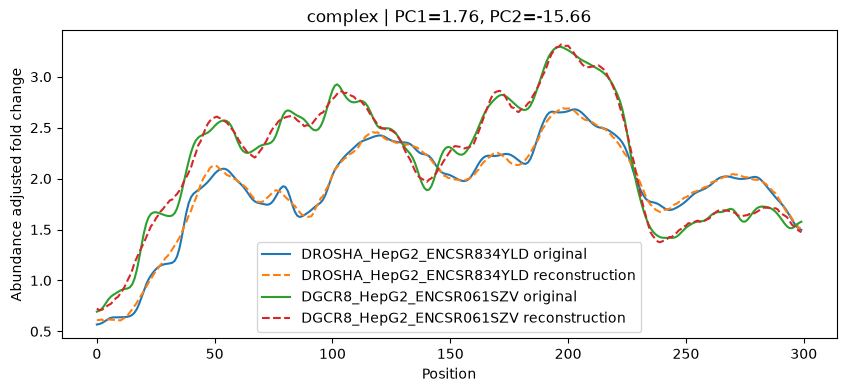

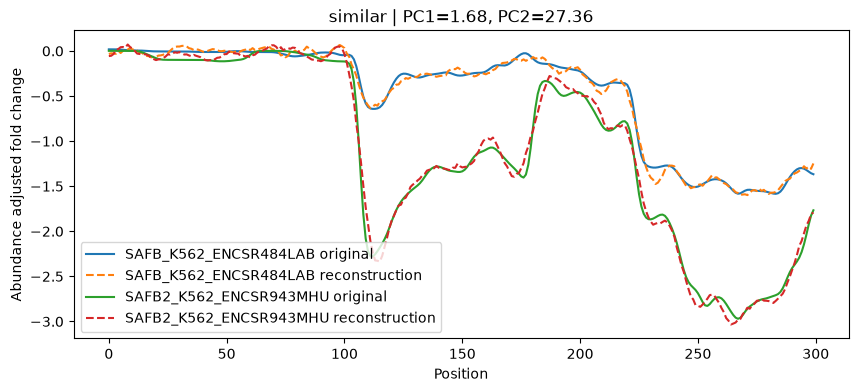

In [17]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc2_bottom[1]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc2_top[-1]
)


What the hell is happening here? How can we have a window with totally negative IP/IN? This must be Skipper's stupid doings again. I am going to assume that there is some absolute nonsense happening here relating to the damn GC content shit. 

### PC3

In [18]:
pc3_order = pca_df["PC3"].sort_values().index
pc3_bottom = pc3_order[:100]
pc3_top = pc3_order[-100:]

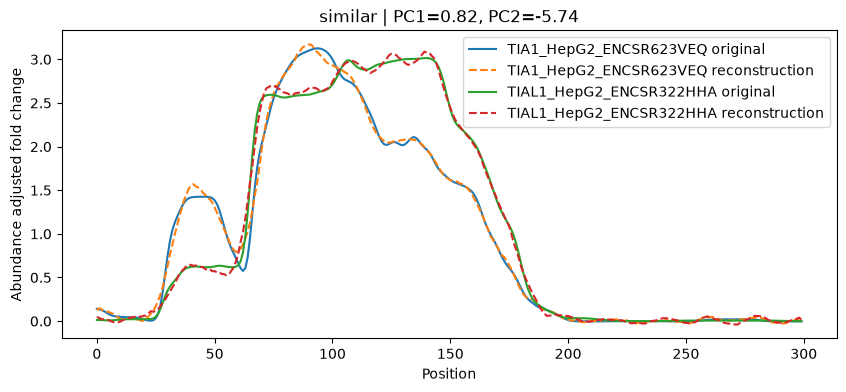

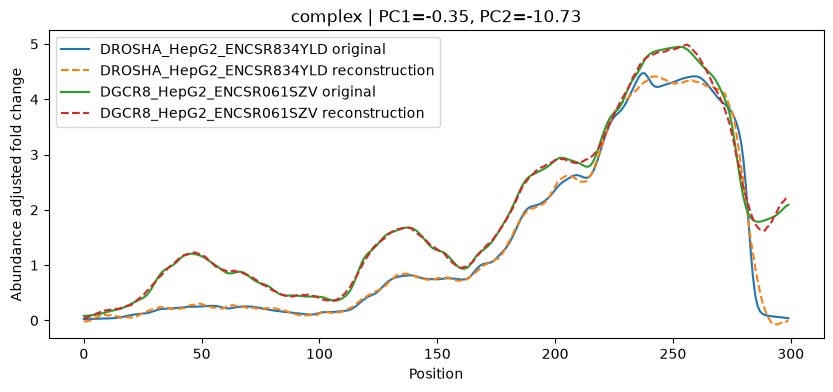

In [19]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc3_bottom[1]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc3_top[-1]
)


### PC10

In [20]:
pc10_order = pca_df["PC10"].sort_values().index
pc10_bottom = pc10_order[:100]
pc10_top = pc10_order[-100:]


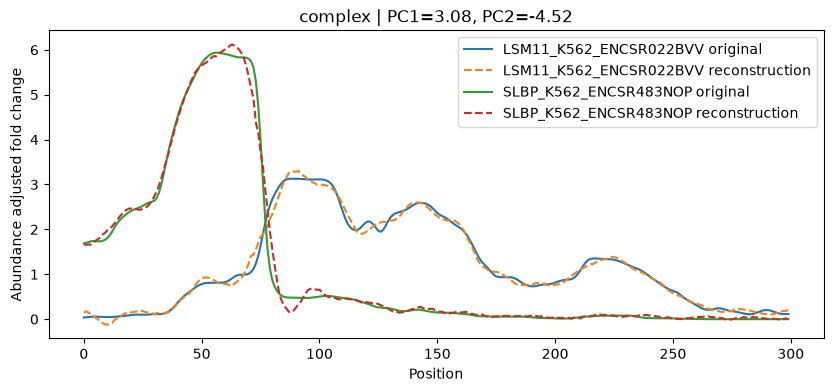

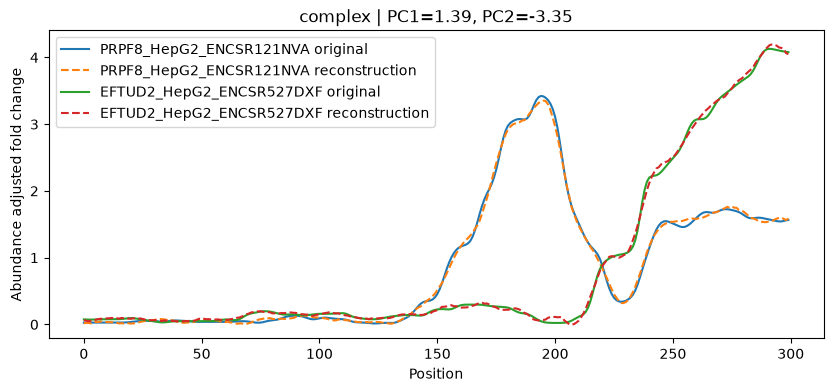

In [21]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc10_bottom[6]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc10_top[-6]
)


# Metric validation

In [22]:
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine

def calculate_window_diagnostics(validation_signals, center_start=125, center_end=175):
    diagnostics = []
    positions = np.arange(validation_signals.shape[2])

    for window in validation_signals:
        signal_A = window[0]
        signal_B = window[1]

        total_signal = signal_A.sum() + signal_B.sum()
        total_abs_signal = np.abs(signal_A).sum() + np.abs(signal_B).sum()

        # Signed and absolute channel properties.
        sum_A = signal_A.sum()
        sum_B = signal_B.sum()
        abs_sum_A = np.abs(signal_A).sum()
        abs_sum_B = np.abs(signal_B).sum()

        # Correlation / similarity.
        if np.std(signal_A) == 0 or np.std(signal_B) == 0:
            pearson = 0
            spearman = 0
        else:
            pearson = pearsonr(signal_A, signal_B).statistic
            spearman = spearmanr(signal_A, signal_B).statistic

        if np.linalg.norm(signal_A) == 0 or np.linalg.norm(signal_B) == 0:
            cosine_sim = 0
        else:
            cosine_sim = 1 - cosine(signal_A, signal_B)

        # Channel differences.
        mean_difference = np.mean(signal_A - signal_B)
        sum_difference = np.sum(signal_A - signal_B)
        mean_abs_difference = np.mean(np.abs(signal_A - signal_B))
        sum_abs_difference = np.sum(np.abs(signal_A - signal_B))

        total_abs_signal = abs_sum_A + abs_sum_B
        channel_dominance = (
            (sum_A - sum_B) / total_abs_signal
            if total_abs_signal > 0 else 0
        )

        # Strongest absolute signal positions.
        peak_A = np.argmax(np.abs(signal_A)) if abs_sum_A > 0 else np.nan
        peak_B = np.argmax(np.abs(signal_B)) if abs_sum_B > 0 else np.nan
        peak_distance = abs(peak_A - peak_B) if not np.isnan(peak_A) and not np.isnan(peak_B) else np.nan

        # Center of mass based on absolute signal magnitude.
        center_A = np.sum(positions * np.abs(signal_A)) / abs_sum_A if abs_sum_A > 0 else np.nan
        center_B = np.sum(positions * np.abs(signal_B)) / abs_sum_B if abs_sum_B > 0 else np.nan

        if np.isnan(center_A) and np.isnan(center_B):
            mean_center = np.nan
        else:
            mean_center = np.nanmean([center_A, center_B])

        # Combine absolute signal for general spatial metrics.
        combined_signal = np.abs(signal_A) + np.abs(signal_B)

        midpoint = len(combined_signal) // 2
        left_signal = combined_signal[:midpoint].sum()
        right_signal = combined_signal[midpoint:].sum()

        total_lr = left_signal + right_signal
        left_right_asymmetry = (
            (right_signal - left_signal) / total_lr
            if total_lr > 0 else 0
        )

        # Center versus flanking signal.
        center_signal = combined_signal[center_start:center_end].sum()
        flank_signal = combined_signal[:center_start].sum() + combined_signal[center_end:].sum()
        center_flank_difference = center_signal - flank_signal

        diagnostics.append({
            "pearson_AB": pearson,
            "spearman_AB": spearman,
            "cosine_similarity": cosine_sim,
            "mean_difference": mean_difference,
            "total_signal": total_signal,
            "total_abs_signal": total_abs_signal,
            "sum_difference": sum_difference,
            "mean_abs_difference": mean_abs_difference,
            "sum_abs_difference": sum_abs_difference,
            "channel_dominance": channel_dominance,
            "peak_A_position": peak_A,
            "peak_B_position": peak_B,
            "peak_distance": peak_distance,
            "center_of_mass_A": center_A,
            "center_of_mass_B": center_B,
            "mean_center_of_mass": mean_center,
            "left_signal": left_signal,
            "right_signal": right_signal,
            "left_right_asymmetry": left_right_asymmetry,
            "center_signal": center_signal,
            "flank_signal": flank_signal,
            "center_flank_difference": center_flank_difference
        })

    return(pd.DataFrame(diagnostics))

In [23]:
diagnostic_df = calculate_window_diagnostics(validation_signals)

pca_df = pd.concat(
    [pca_df.reset_index(drop=True), diagnostic_df.reset_index(drop=True)],
    axis=1
)

## Correlation

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

pca_df = pca_df.loc[:, ~pca_df.columns.duplicated(keep="last")]

pc_columns = [f"PC{i}" for i in range(1, 11)]

diagnostic_columns = [
    "pearson_AB", "spearman_AB", "cosine_similarity",
    "mean_difference", "sum_difference", "mean_abs_difference", "sum_abs_difference", "channel_dominance",
    "total_signal", "total_abs_signal",
    "peak_A_position", "peak_B_position", "peak_distance",
    "center_of_mass_A", "center_of_mass_B", "mean_center_of_mass",
    "left_signal", "right_signal", "left_right_asymmetry",
    "center_signal", "flank_signal", "center_flank_difference"
]

correlation_matrix = pd.DataFrame(
    {pc: [pca_df[metric].corr(pca_df[pc], method="spearman") for metric in diagnostic_columns] for pc in pc_columns},
    index=diagnostic_columns
)

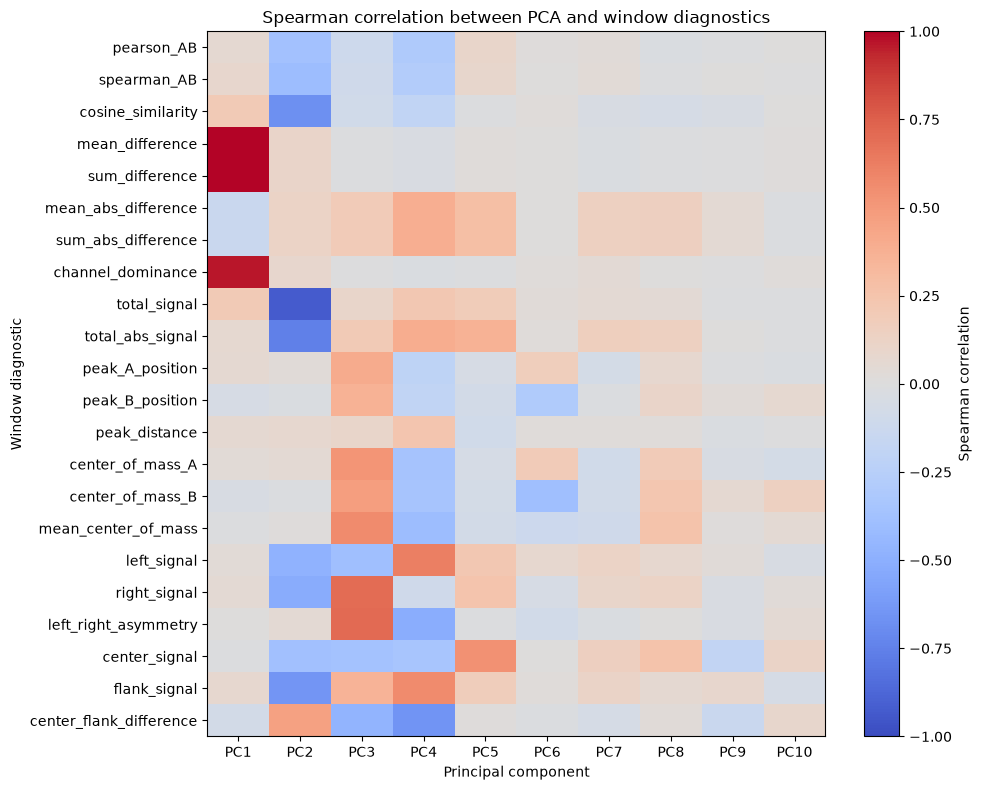

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

heatmap = ax.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(np.arange(len(pc_columns)))
ax.set_xticklabels(pc_columns)

ax.set_yticks(np.arange(len(diagnostic_columns)))
ax.set_yticklabels(diagnostic_columns)

ax.set_xlabel("Principal component")
ax.set_ylabel("Window diagnostic")
ax.set_title("Spearman correlation between PCA and window diagnostics")

fig.colorbar(heatmap, ax=ax, label="Spearman correlation")

plt.tight_layout()
plt.show()

In [26]:
for pc in pc_columns:
    strongest_metric = correlation_matrix[pc].abs().idxmax()
    correlation = correlation_matrix.loc[strongest_metric, pc]

    print(f"{pc}: {strongest_metric} ({correlation:.3f})")

PC1: sum_difference (0.992)
PC2: total_signal (-0.928)
PC3: left_right_asymmetry (0.707)
PC4: center_flank_difference (-0.655)
PC5: center_signal (0.532)
PC6: center_of_mass_B (-0.386)
PC7: total_abs_signal (0.159)
PC8: mean_center_of_mass (0.252)
PC9: center_signal (-0.184)
PC10: center_of_mass_B (0.145)


# Quick test

In [27]:
test1 = pd.read_table("~/projects/encode_skipper2_output/secondary_results/tested_windows/SAFB_K562_ENCSR484LAB.SAFB_K562_ENCSR484LAB_IP_1.tested_windows.tsv.gz")

In [28]:
test2 = pd.read_table("~/projects/encode_skipper2_output/secondary_results/tested_windows/SAFB2_K562_ENCSR943MHU.SAFB2_K562_ENCSR943MHU_IP_1.tested_windows.tsv.gz")

In [29]:
test1["gc_bin_in_ip_ratio"].unique()

array([1.20428078, 0.43831279, 0.5406935 , 0.365598  , 0.42006609,
       0.76751233, 0.36870381, 0.3600043 , 3.04824882, 0.4171422 ])

In [30]:
test2["gc_bin_in_ip_ratio"].unique()

array([0.79742966, 0.34594646, 0.50833359, 0.36122877, 0.39265575,
       0.62248297, 0.30609272, 0.30546997, 1.33170711, 0.32845438])

Oh god, another potential redo. Great. Love it. Will have to check and see if the reason that certain bins look so funky is because of stuff like extreme IP/IN values, and I will need to go back to the idea that this entire method of GC content is just stupid in this context (if the RBP binds to GC rich regions, then of course there is a lot of signal in high GC content bins. Why should we have less power to detect binding in those bins because there more binding?)